In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.append("../../utils/py")
import miniramses as ram

plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 180
plt.rcParams.update({
    "font.size": 14,
    "legend.fontsize": 12,
})

G = 1.0


In [31]:
# -----------------------------
# User configuration
# -----------------------------
prefix = "grav"

# Slice definition: keep cells whose volume intersects this plane.
slice_axis = "z"

# Optional plotting box [xmin, xmax, ymin, ymax] in the slice plane.
plot_box = [1,3,1,3]
#plot_box = [300,900,300,900]
slice_center = 0.5 * (plot_box[0] + plot_box[1])

# Double-sphere parameters in code units.
rho = 1.0
sphere1_center = np.array([1.7, 2.0, 2.0])
sphere2_center = np.array([2.2, 2.0, 2.0])
sphere1_radius = 0.1
sphere2_radius = 0.2


In [32]:
# -----------------------------
# Analytic double-sphere solution
# -----------------------------
def _uniform_sphere_mass(radius, density=rho):
    return (4.0 / 3.0) * np.pi * radius**3 * density


def _sphere_offsets(x, y, z, center):
    dx = x - center[0]
    dy = y - center[1]
    dz = z - center[2]
    r = np.sqrt(dx**2 + dy**2 + dz**2)
    r = np.maximum(r, 1.0e-14)
    return dx, dy, dz, r


def phi_uniform_sphere(r, radius, mass):
    phi_out = -G * mass / r
    phi_in = -1.5 * G * mass / radius + 0.5 * G * mass * r**2 / radius**3
    return np.where(r >= radius, phi_out, phi_in)


def force_component_uniform_sphere(delta, r, radius, mass):
    f_out = -G * mass * delta / r**3
    f_in = -G * mass * delta / radius**3
    return np.where(r >= radius, f_out, f_in)


def analytic_double_sphere(x, y, z):
    """Return analytic phi, fx, fy, fz, |f| at arbitrary AMR cell centers."""
    m1 = _uniform_sphere_mass(sphere1_radius)
    m2 = _uniform_sphere_mass(sphere2_radius)

    dx1, dy1, dz1, r1 = _sphere_offsets(x, y, z, sphere1_center)
    dx2, dy2, dz2, r2 = _sphere_offsets(x, y, z, sphere2_center)

    phi = phi_uniform_sphere(r1, sphere1_radius, m1) + phi_uniform_sphere(r2, sphere2_radius, m2)
    fx = force_component_uniform_sphere(dx1, r1, sphere1_radius, m1) + force_component_uniform_sphere(dx2, r2, sphere2_radius, m2)
    fy = force_component_uniform_sphere(dy1, r1, sphere1_radius, m1) + force_component_uniform_sphere(dy2, r2, sphere2_radius, m2)
    fz = force_component_uniform_sphere(dz1, r1, sphere1_radius, m1) + force_component_uniform_sphere(dz2, r2, sphere2_radius, m2)
    fmag = np.sqrt(fx**2 + fy**2 + fz**2)

    return {
        "phi": phi,
        "fx": fx,
        "fy": fy,
        "fz": fz,
        "f": fmag,
    }


In [33]:
# -----------------------------
# AMR loading and slicing helpers
# -----------------------------
AXIS_TO_INDEX = {"x": 0, "y": 1, "z": 2}


def load_grav_cells(nout, path=path, prefix=prefix):
    c = ram.rd_cell(str(nout), path=path, prefix=prefix)
    info = ram.rd_info(str(nout), path=path)
    return c, info


def slice_cells(c, axis=slice_axis, center=slice_center, levels=None):
    axis = axis.lower()
    if axis not in AXIS_TO_INDEX:
        raise ValueError(f"axis must be one of {tuple(AXIS_TO_INDEX)}, got {axis!r}")

    axis_idx = AXIS_TO_INDEX[axis]
    mask = np.abs(c.x[axis_idx] - center) <= c.dx / 2.0

    if levels is not None:
        mask &= np.isin(c.level, np.asarray(levels))

    data = {
        "mask": mask,
        "x3d": c.x[0][mask],
        "y3d": c.x[1][mask],
        "z3d": c.x[2][mask],
        "dx": c.dx[mask],
        "level": c.level[mask],
        "level_plot": c.level[mask] + 1,
        "phi_sim": c.g[0][mask],
        "fx_sim": c.g[1][mask],
        "fy_sim": c.g[2][mask],
        "fz_sim": c.g[3][mask],
    }
    data["f_sim"] = np.sqrt(data["fx_sim"]**2 + data["fy_sim"]**2 + data["fz_sim"]**2)

    analytic = analytic_double_sphere(data["x3d"], data["y3d"], data["z3d"])
    for key, value in analytic.items():
        data[f"{key}_ana"] = value
        sim_key = f"{key}_sim"
        if sim_key in data:
            with np.errstate(divide="ignore", invalid="ignore"):
                data[f"{key}_relerr"] = np.where(np.abs(value) > 0.0, (data[sim_key] - value) / value, np.nan)

    if axis == "x":
        data["u"] = data["y3d"]
        data["v"] = data["z3d"]
        data["plane_axes"] = ("y", "z")
    elif axis == "y":
        data["u"] = data["x3d"]
        data["v"] = data["z3d"]
        data["plane_axes"] = ("x", "z")
    else:
        data["u"] = data["x3d"]
        data["v"] = data["y3d"]
        data["plane_axes"] = ("x", "y")

    return data


def slice_dataframe(s):
    return pd.DataFrame({
        "x": s["x3d"],
        "y": s["y3d"],
        "z": s["z3d"],
        "u": s["u"],
        "v": s["v"],
        "dx": s["dx"],
        "level": s["level"],
        "level_plot": s["level_plot"],
        "phi_sim": s["phi_sim"],
        "phi_ana": s["phi_ana"],
        "phi_relerr": s["phi_relerr"],
        "fx_sim": s["fx_sim"],
        "fy_sim": s["fy_sim"],
        "fz_sim": s["fz_sim"],
        "f_sim": s["f_sim"],
        "f_ana": s["f_ana"],
        "f_relerr": s["f_relerr"],
    })


In [34]:
# -----------------------------
# Refinement-region summaries
# -----------------------------
def refinement_summary(s):
    records = []
    for lev in np.sort(np.unique(s["level"])):
        keep = s["level"] == lev
        if not np.any(keep):
            continue
        u = s["u"][keep]
        v = s["v"][keep]
        dx = s["dx"][keep]
        records.append({
            "level": int(lev + 1),
            "ncell": int(np.count_nonzero(keep)),
            "dx": float(dx[0]),
            "u_min": float(np.min(u - dx / 2.0)),
            "u_max": float(np.max(u + dx / 2.0)),
            "v_min": float(np.min(v - dx / 2.0)),
            "v_max": float(np.max(v + dx / 2.0)),
        })
    return pd.DataFrame(records)


def show_refinement_summary(s):
    df = refinement_summary(s)
    if df.empty:
        print("No cells intersect this slice.")
        return df
    display(df)
    return df


In [35]:
# -----------------------------
# Visualization helpers
# -----------------------------
def show_amr_field(s, field, *, levels=None, box=plot_box, npix=900, grid=False,
                   cmap="magma", log=False, vmin=None, vmax=None):
    keep = np.ones_like(s["level"], dtype=bool)
    if levels is not None:
        keep &= np.isin(s["level"], np.asarray(levels))

    if not np.any(keep):
        raise ValueError("No slice cells survive the requested level filter.")

    return ram.visu(
        s["u"][keep],
        s["v"][keep],
        s["dx"][keep],
        s[field][keep],
        s["level_plot"][keep],
        npix=npix,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        box=box,
        grid=grid,
        log=log,
    )


def plot_refinement_map(s, box=plot_box, npix=900):
    return show_amr_field(
        s,
        "level_plot",
        box=box,
        npix=npix,
        grid=True,
        cmap="viridis",
    )


def compare_scalar_field(s, quantity="phi", box=plot_box, npix=900, log=False, grid=False):
    sim_key = f"{quantity}_sim"
    ana_key = f"{quantity}_ana"
    err_key = f"{quantity}_relerr"

    if sim_key not in s or ana_key not in s or err_key not in s:
        raise KeyError(f"Unknown quantity {quantity!r}")

    sim_vals = s[sim_key]
    if quantity == "f":
        print(np.min(sim_vals))
    ana_vals = s[ana_key]
    err_vals = s[err_key]

    finite_vals = np.concatenate([sim_vals[np.isfinite(sim_vals)], ana_vals[np.isfinite(ana_vals)]])
    vmin = float(np.min(finite_vals))
    vmax = float(np.max(finite_vals))

    print(f"Simulation {quantity}")
    show_amr_field(s, sim_key, box=box, npix=npix, cmap="magma", log=log, vmin=vmin, vmax=vmax, grid=grid)

    print(f"Analytic {quantity}")
    show_amr_field(s, ana_key, box=box, npix=npix, cmap="magma", log=log, vmin=vmin, vmax=vmax, grid=grid)

    vmax_err = float(np.nanmax(np.abs(err_vals)))
    if not np.isfinite(vmax_err) or vmax_err == 0.0:
        vmax_err = 1.0e-16

    print(f"Relative error in {quantity}")
    show_amr_field(s, err_key, box=box, npix=npix, cmap="RdBu_r", log=False, vmin=-vmax_err, vmax=vmax_err, grid=grid)


def plot_level_error_stats(s, quantity="phi"):
    err_key = f"{quantity}_relerr"
    levels = np.sort(np.unique(s["level"]))
    levels_plot = levels + 1
    means = []
    maxes = []

    for lev in levels:
        keep = s["level"] == lev
        err = np.abs(s[err_key][keep])
        err = err[np.isfinite(err)]
        means.append(np.nan if err.size == 0 else np.mean(err))
        maxes.append(np.nan if err.size == 0 else np.max(err))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(levels_plot, means, "o-", label="mean |relative error|")
    ax.plot(levels_plot, maxes, "s-", label="max |relative error|")
    ax.set_xlabel("AMR level")
    ax.set_ylabel(f"|relative error| in {quantity}")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


def plot_midline_profile(s, quantity="phi", axis_in_plane="u", coord=None, atol=None):
    if axis_in_plane not in {"u", "v"}:
        raise ValueError("axis_in_plane must be 'u' or 'v'")

    transverse = "v" if axis_in_plane == "u" else "u"
    label_main, label_transverse = s["plane_axes"] if axis_in_plane == "u" else s["plane_axes"][::-1]

    if coord is None:
        coord = 0.5 * (np.min(s[transverse]) + np.max(s[transverse]))
    if atol is None:
        atol = np.min(s["dx"]) / 2.0

    keep = np.abs(s[transverse] - coord) <= atol
    if not np.any(keep):
        transverse_values = s[transverse]
        nearest = transverse_values[np.argmin(np.abs(transverse_values - coord))]
        coord = float(nearest)
        keep = np.abs(s[transverse] - coord) <= np.min(s["dx"]) / 2.0
    if not np.any(keep):
        raise ValueError("No slice cells intersect the requested profile band.")

    order = np.argsort(s[axis_in_plane][keep])
    x = s[axis_in_plane][keep][order]
    sim = s[f"{quantity}_sim"][keep][order]
    ana = s[f"{quantity}_ana"][keep][order]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, ana, "k-", lw=1.5, label="analytic")
    ax.plot(x, sim, "o", ms=3, alpha=0.8, label="AMR cells")
    ax.set_xlabel(label_main)
    ax.set_ylabel(quantity)
    ax.set_title(f"{quantity} profile near {label_transverse} = {coord:.4f}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


In [36]:
def compare_two_solutions_with_analytic(
    s1,
    s2,
    quantity="phi",
    *,
    box=plot_box,
    npix=900,
    cmap_value="magma",
    cmap_err="RdBu_r",
    titles=("s1", "s2", "analytic"),
    err_mode="signed",   # "signed" or "abs"
    grid=False,
    exclude_boundary=False,
):
    """
    Compare two AMR solutions against analytic in a 3x2 panel.

    New:
        exclude_boundary: remove cells touching box edges
        boundary_tol: distance from edge to exclude (default ~ half cell size)
    """
    
    boundary_tol = 2 * 2/2 ** min(s1['level'])

    sim_key = f"{quantity}_sim"
    ana_key = f"{quantity}_ana"
    err_key = f"{quantity}_relerr"

    for name, s in [("s1", s1), ("s2", s2)]:
        for key in (sim_key, ana_key, err_key, "u", "v", "dx", "level_plot"):
            if key not in s:
                raise KeyError(f"{name} missing {key!r}")

    # -----------------------------
    # Boundary masking helper
    # -----------------------------
    def make_mask(s):
        mask = np.ones_like(s["u"], dtype=bool)

        if exclude_boundary:
            tol = boundary_tol
            if tol is None:
                tol = 0.5 * np.min(s["dx"])

            xmin, xmax, ymin, ymax = box

            mask &= (s["u"] > xmin + tol)
            mask &= (s["u"] < xmax - tol)
            mask &= (s["v"] > ymin + tol)
            mask &= (s["v"] < ymax - tol)

        return mask

    mask1 = make_mask(s1)
    mask2 = make_mask(s2)

    # -----------------------------
    # Row 1 scaling
    # -----------------------------
    val_arrays = [
        s1[sim_key][mask1 & np.isfinite(s1[sim_key])],
        s2[sim_key][mask2 & np.isfinite(s2[sim_key])],
        s1[ana_key][mask1 & np.isfinite(s1[ana_key])],
    ]
    val_arrays = [a for a in val_arrays if a.size > 0]
    if len(val_arrays) == 0:
        raise ValueError("No finite values after masking.")

    vmin_val = float(min(np.min(a) for a in val_arrays))
    vmax_val = float(max(np.max(a) for a in val_arrays))

    # -----------------------------
    # Row 2 scaling
    # -----------------------------
    err1 = s1[err_key][mask1]
    err2 = s2[err_key][mask2]

    if err_mode == "signed":
        vmax_err = np.nanmax([
            np.nanmax(np.abs(err1[np.isfinite(err1)])) if np.any(np.isfinite(err1)) else 0.0,
            np.nanmax(np.abs(err2[np.isfinite(err2)])) if np.any(np.isfinite(err2)) else 0.0,
        ])
        if not np.isfinite(vmax_err) or vmax_err == 0.0:
            vmax_err = 1e-16
        vmin_err, vmax_err = -float(vmax_err), float(vmax_err)

    elif err_mode == "abs":
        finite_err = []
        if np.any(np.isfinite(err1)):
            finite_err.append(np.abs(err1[np.isfinite(err1)]))
        if np.any(np.isfinite(err2)):
            finite_err.append(np.abs(err2[np.isfinite(err2)]))

        if len(finite_err) == 0:
            vmin_err, vmax_err = 0.0, 1e-16
        else:
            vmin_err = 0.0
            vmax_err = float(max(np.max(a) for a in finite_err))
            if vmax_err == 0.0:
                vmax_err = 1e-16
    else:
        raise ValueError("err_mode must be 'signed' or 'abs'")

    # -----------------------------
    # Plot
    # -----------------------------
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

    datasets_top = [
        (s1, mask1, sim_key, titles[0]),
        (s2, mask2, sim_key, titles[1]),
        (s1, mask1, ana_key, titles[2]),
    ]

    datasets_bottom = [
        (s1, mask1, err_key, titles[0]),
        (s2, mask2, err_key, titles[1]),
        (s1, mask1, None, titles[2]),
    ]

    # -----------------------------
    # Top row
    # -----------------------------
    mappable_top = None
    for j, (s, m, key, title) in enumerate(datasets_top):
        ax = axes[0, j]
        vals = s[key][m]

        im = ax.scatter(
            s["u"][m],
            s["v"][m],
            c=vals,
            s=np.maximum(4, 8000.0 * s["dx"][m] / (box[1] - box[0])),
            cmap=cmap_value,
            vmin=vmin_val,
            vmax=vmax_val,
            marker="s",
            linewidths=0,
        )
        mappable_top = im

        if grid:
            ax.scatter(s["u"][m], s["v"][m], s=1, c="k", alpha=0.15, linewidths=0)

        ax.set_title(title)
        ax.set_xlim(box[0], box[1])
        ax.set_ylim(box[2], box[3])
        ax.set_aspect("equal")
        if j == 0:
            ax.set_ylabel(quantity)
        ax.set_xticks([])
        ax.set_yticks([])

    fig.colorbar(mappable_top, ax=axes[0, :], shrink=0.92, pad=0.02)

    # -----------------------------
    # Bottom row
    # -----------------------------
    mappable_bottom = None
    for j, (s, m, key, title) in enumerate(datasets_bottom):
        ax = axes[1, j]

        if key is None:
            vals = np.zeros_like(s["u"][m])
        else:
            vals = s[key][m]
            if err_mode == "abs":
                vals = np.abs(vals)

        im = ax.scatter(
            s["u"][m],
            s["v"][m],
            c=vals,
            s=np.maximum(4, 8000.0 * s["dx"][m] / (box[1] - box[0])),
            cmap=cmap_err,
            vmin=vmin_err,
            vmax=vmax_err,
            marker="s",
            linewidths=0,
        )
        mappable_bottom = im

        if grid:
            ax.scatter(s["u"][m], s["v"][m], s=1, c="k", alpha=0.15, linewidths=0)

        ax.set_title(title)
        ax.set_xlim(box[0], box[1])
        ax.set_ylim(box[2], box[3])
        ax.set_aspect("equal")
        if j == 0:
            ax.set_ylabel(f"{quantity} rel. err")
        ax.set_xticks([])
        ax.set_yticks([])

    fig.colorbar(mappable_bottom, ax=axes[1, :], shrink=0.92, pad=0.02)

    plt.show()

In [37]:
def ready(nout, path):
    c, info = load_grav_cells(nout, path)
    print(f"Loaded output_{int(nout):05d} from {Path(path).resolve()}")
    print(f"ndim = {c.ndim}, ncell = {c.ncell}")
    print(f"levelmin = {info.levelmin}, nlevelmax = {info.nlevelmax}")
    print("levels present:", np.unique(c.level + 1))
    s = slice_cells(c, axis=slice_axis, center=slice_center)
    print(f"slice axis   : {slice_axis}")
    print(f"slice center : {slice_center}")
    print(f"slice cells  : {len(s['level'])}")
    print("slice levels:", np.unique(s["level_plot"]))

    return c, s


In [38]:
def compare_two_solutions(
    s1,
    s2,
    quantity="phi",
    *,
    box=plot_box,
    npix=900,
    cmap_value="magma",
    cmap_diff="RdYlGn",
    titles=("s1", "s2", "rel. diff"),
    diff_mode="signed",   # "signed" or "abs"
    grid=False,
    exclude_boundary=False,
    log=False
):
    """
    Compare two AMR solutions in a 1x3 panel:
        [s1, s2, (s1 - s2)/s1]

    Parameters
    ----------
    s1, s2 : dict-like
        Must contain:
            u, v, dx, level_plot,
            and either:
              - f"{quantity}_sim"
            or
              - quantity
    quantity : str
        Field name, e.g. "phi", "fx", ...
    box : sequence of 4 floats
        [xmin, xmax, ymin, ymax]
    cmap_value : str
        Colormap for s1 and s2
    cmap_diff : str
        Colormap for the relative-difference panel
    titles : 3-tuple of str
        Titles for the three panels
    diff_mode : {"signed", "abs"}
        Only used when log=False.
        - "signed": show signed (s1 - s2)/s1
        - "abs": show abs((s1 - s2)/s1)
    grid : bool
        If True, overplot faint point centers
    exclude_boundary : bool
        If True, exclude cells too close to the plot box boundary
    log : bool
        If True:
        - first two panels plot log10(abs(value))
        - third panel plots log10(abs((s1 - s2)/s1))
    """

    import numpy as np
    import matplotlib.pyplot as plt

    boundary_tol = 2 * 2 / 2 ** min(s1["level"])

    # try quantity_sim first, then quantity
    val_key = f"{quantity}_sim" if f"{quantity}_sim" in s1 else quantity

    for name, s in [("s1", s1), ("s2", s2)]:
        for key in (val_key, "u", "v", "dx", "level_plot"):
            if key not in s:
                raise KeyError(f"{name} missing {key!r}")

    # -----------------------------
    # Helpers
    # -----------------------------
    def make_mask(s):
        mask = np.ones_like(s["u"], dtype=bool)

        if exclude_boundary:
            tol = boundary_tol
            xmin, xmax, ymin, ymax = box
            mask &= (s["u"] > xmin + tol)
            mask &= (s["u"] < xmax - tol)
            mask &= (s["v"] > ymin + tol)
            mask &= (s["v"] < ymax - tol)

        return mask

    def log_transform(arr):
        arr = np.asarray(arr, dtype=float)
        out = np.full_like(arr, np.nan, dtype=float)

        finite = np.isfinite(arr)
        nonzero = finite & (np.abs(arr) > 0.0)
        out[nonzero] = np.log10(np.abs(arr[nonzero]))
        return out

    def finite_minmax(arr_list, fallback=(0.0, 1.0)):
        vals = []
        for a in arr_list:
            a = np.asarray(a)
            good = a[np.isfinite(a)]
            if good.size > 0:
                vals.append(good)

        if not vals:
            return fallback

        vmin = min(np.min(a) for a in vals)
        vmax = max(np.max(a) for a in vals)
        return float(vmin), float(vmax)

    def point_sizes(dxvals):
        return np.maximum(4, 8000.0 * dxvals / (box[1] - box[0]))

    # -----------------------------
    # Masks
    # -----------------------------
    mask1 = make_mask(s1)
    mask2 = make_mask(s2)

    # Require same number of kept cells
    if np.count_nonzero(mask1) != np.count_nonzero(mask2):
        raise ValueError("s1 and s2 have different numbers of kept cells after masking.")

    u1 = np.asarray(s1["u"][mask1])
    v1 = np.asarray(s1["v"][mask1])
    dx1 = np.asarray(s1["dx"][mask1])

    u2 = np.asarray(s2["u"][mask2])
    v2 = np.asarray(s2["v"][mask2])
    dx2 = np.asarray(s2["dx"][mask2])

    val1_raw = np.asarray(s1[val_key][mask1], dtype=float)
    val2_raw = np.asarray(s2[val_key][mask2], dtype=float)

    # Optional sanity check that coordinates match
    if not (np.allclose(u1, u2) and np.allclose(v1, v2) and np.allclose(dx1, dx2)):
        raise ValueError("s1 and s2 grids do not align cell-by-cell after masking.")

    # -----------------------------
    # Relative difference
    # -----------------------------
    rel_diff_raw = np.full_like(val1_raw, np.nan, dtype=float)
    good = np.isfinite(val1_raw) & np.isfinite(val2_raw) & (np.abs(val1_raw) > 0.0)
    rel_diff_raw[good] = (val1_raw[good] - val2_raw[good]) / val1_raw[good]

    # -----------------------------
    # Plot data
    # -----------------------------
    if log:
        val1_plot = log_transform(val1_raw)
        val2_plot = log_transform(val2_raw)
        diff_plot = log_transform(rel_diff_raw)

        vmin_val, vmax_val = finite_minmax([val1_plot, val2_plot], fallback=(-16.0, 0.0))
        vmin_diff, vmax_diff = finite_minmax([diff_plot], fallback=(-16.0, 0.0))
    else:
        val1_plot = val1_raw
        val2_plot = val2_raw

        if diff_mode == "signed":
            diff_plot = rel_diff_raw
            finite_abs = np.abs(diff_plot[np.isfinite(diff_plot)])
            if finite_abs.size == 0:
                vmax_abs = 1e-16
            else:
                vmax_abs = float(np.max(finite_abs))
                if vmax_abs == 0.0:
                    vmax_abs = 1e-16
            vmin_diff, vmax_diff = -vmax_abs, vmax_abs

        elif diff_mode == "abs":
            diff_plot = np.abs(rel_diff_raw)
            finite_abs = diff_plot[np.isfinite(diff_plot)]
            if finite_abs.size == 0:
                vmin_diff, vmax_diff = 0.0, 1e-16
            else:
                vmin_diff = 0.0
                vmax_diff = float(np.max(finite_abs))
                if vmax_diff == 0.0:
                    vmax_diff = 1e-16
        else:
            raise ValueError("diff_mode must be 'signed' or 'abs'")

        vmin_val, vmax_val = finite_minmax([val1_plot, val2_plot])

    if not np.isfinite(vmin_val) or not np.isfinite(vmax_val):
        raise ValueError("Could not determine finite color scale for s1/s2 panels.")

    # -----------------------------
    # Stats for title
    # -----------------------------
    diff_abs = np.abs(rel_diff_raw[np.isfinite(rel_diff_raw)])
    diff_mean = np.nan if diff_abs.size == 0 else np.mean(diff_abs)
    diff_max  = np.nan if diff_abs.size == 0 else np.max(diff_abs)

    # -----------------------------
    # Plot
    # -----------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

    datasets = [
        (axes[0], u1, v1, dx1, val1_plot, titles[0], cmap_value, vmin_val, vmax_val),
        (axes[1], u2, v2, dx2, val2_plot, titles[1], cmap_value, vmin_val, vmax_val),
        (axes[2], u1, v1, dx1, diff_plot, titles[2], cmap_diff, vmin_diff, vmax_diff),
    ]

    mappable_val = None
    mappable_diff = None

    for j, (ax, u, v, dx, vals, title, cmap, vmin, vmax) in enumerate(datasets):
        valid = np.isfinite(vals)
        if not np.any(valid):
            raise ValueError(f"No plottable values for panel {title!r}.")

        im = ax.scatter(
            u[valid],
            v[valid],
            c=vals[valid],
            s=point_sizes(dx[valid]),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            marker="s",
            linewidths=0,
        )

        if j < 2:
            mappable_val = im
        else:
            mappable_diff = im

        if grid:
            ax.scatter(
                u[valid],
                v[valid],
                s=1,
                c="k",
                alpha=0.15,
                linewidths=0,
            )

        if j == 2:
            ax.set_title(f"{title}\nMean: {diff_mean:.2e}, Max: {diff_max:.2e}")
        else:
            ax.set_title(title)

        ax.set_xlim(box[0], box[1])
        ax.set_ylim(box[2], box[3])
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])

    # left colorbar for s1/s2
    cbar_val = fig.colorbar(mappable_val, ax=axes[:2], shrink=0.92, pad=0.02)
    cbar_val.set_label(f"log10(|{quantity}|)" if log else quantity)

    # right colorbar for relative difference
    cbar_diff = fig.colorbar(mappable_diff, ax=axes[2], shrink=0.92, pad=0.02)
    if log:
        cbar_diff.set_label(rf"log10(|(s1-s2)/s1|)")
    else:
        if diff_mode == "signed":
            cbar_diff.set_label(rf"(s1-s2)/s1")
        else:
            cbar_diff.set_label(rf"| (s1-s2)/s1 |")

    plt.show()

In [39]:
path1 = "/scratch/gpfs/jl4415/runs/spheres_compare/fmm/level_09/"
path2 = "/scratch/gpfs/jl4415/runs/spheres_compare/mg/level_09/"

c1, s1 = ready(2, path=path1)
c2, s2 = ready(2, path=path2)

ncpu=1 ndim=3 nlevelmax=9
Time= 0.0740158176646651
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 16777216 leaf cells
Extracting leaf cells...
Loaded output_00002 from /scratch/gpfs/jl4415/runs/spheres_compare/fmm/level_09
ndim = 3, ncell = 16777216
levelmin = 9, nlevelmax = 9
levels present: [9]
slice axis   : z
slice center : 2.0
slice cells  : 131072
slice levels: [9]
ncpu=1 ndim=3 nlevelmax=9
Time= 0.0732807902609257
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 16777216 leaf cells
Extracting leaf cells...
Loaded output_00002 from /scratch/gpfs/jl4415/runs/spheres_compare/mg/level_09
ndim = 3, ncell = 16777216
levelmin = 9, nlevelmax = 9
levels present: [9]
slice axis   : z
slice center : 2.0
slice cells  : 131072
slice levels: [9]


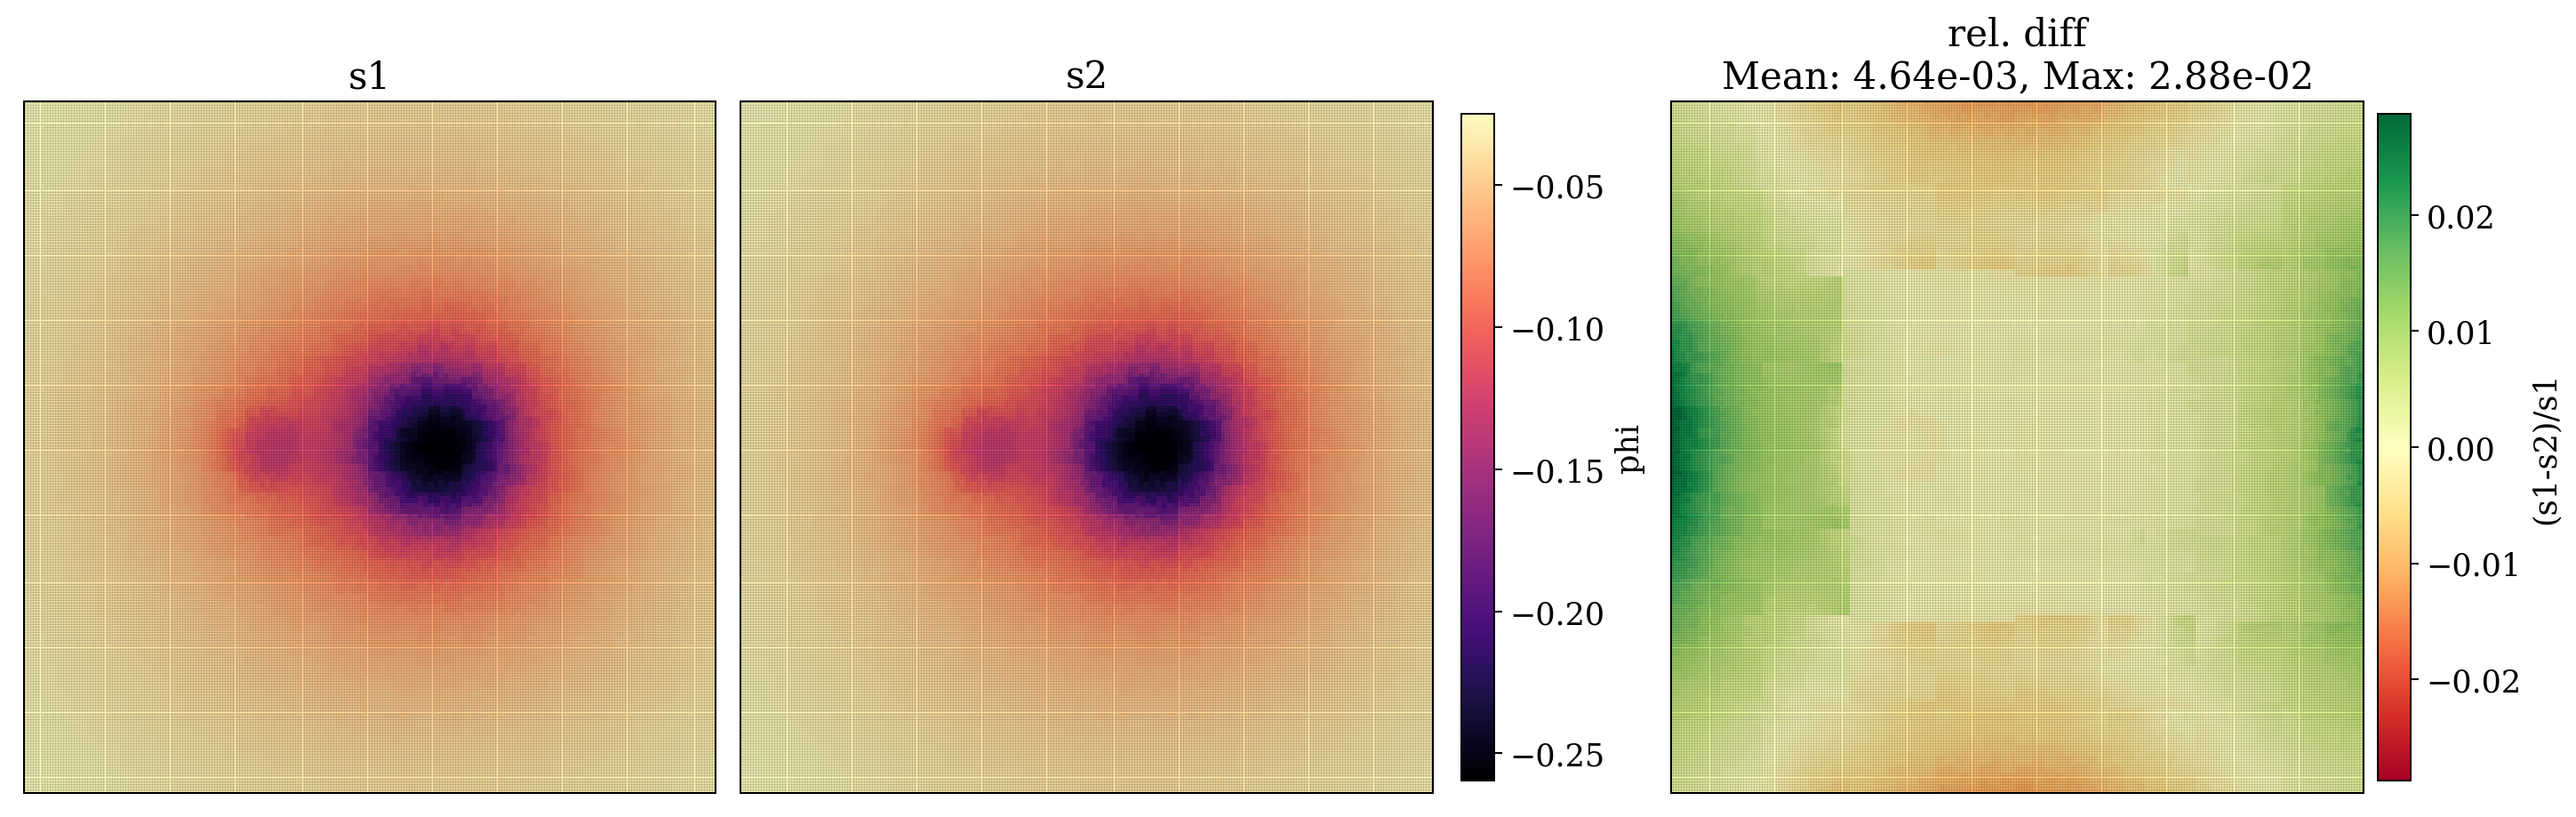

In [40]:
compare_two_solutions(s1, s2, quantity="phi", grid=True)

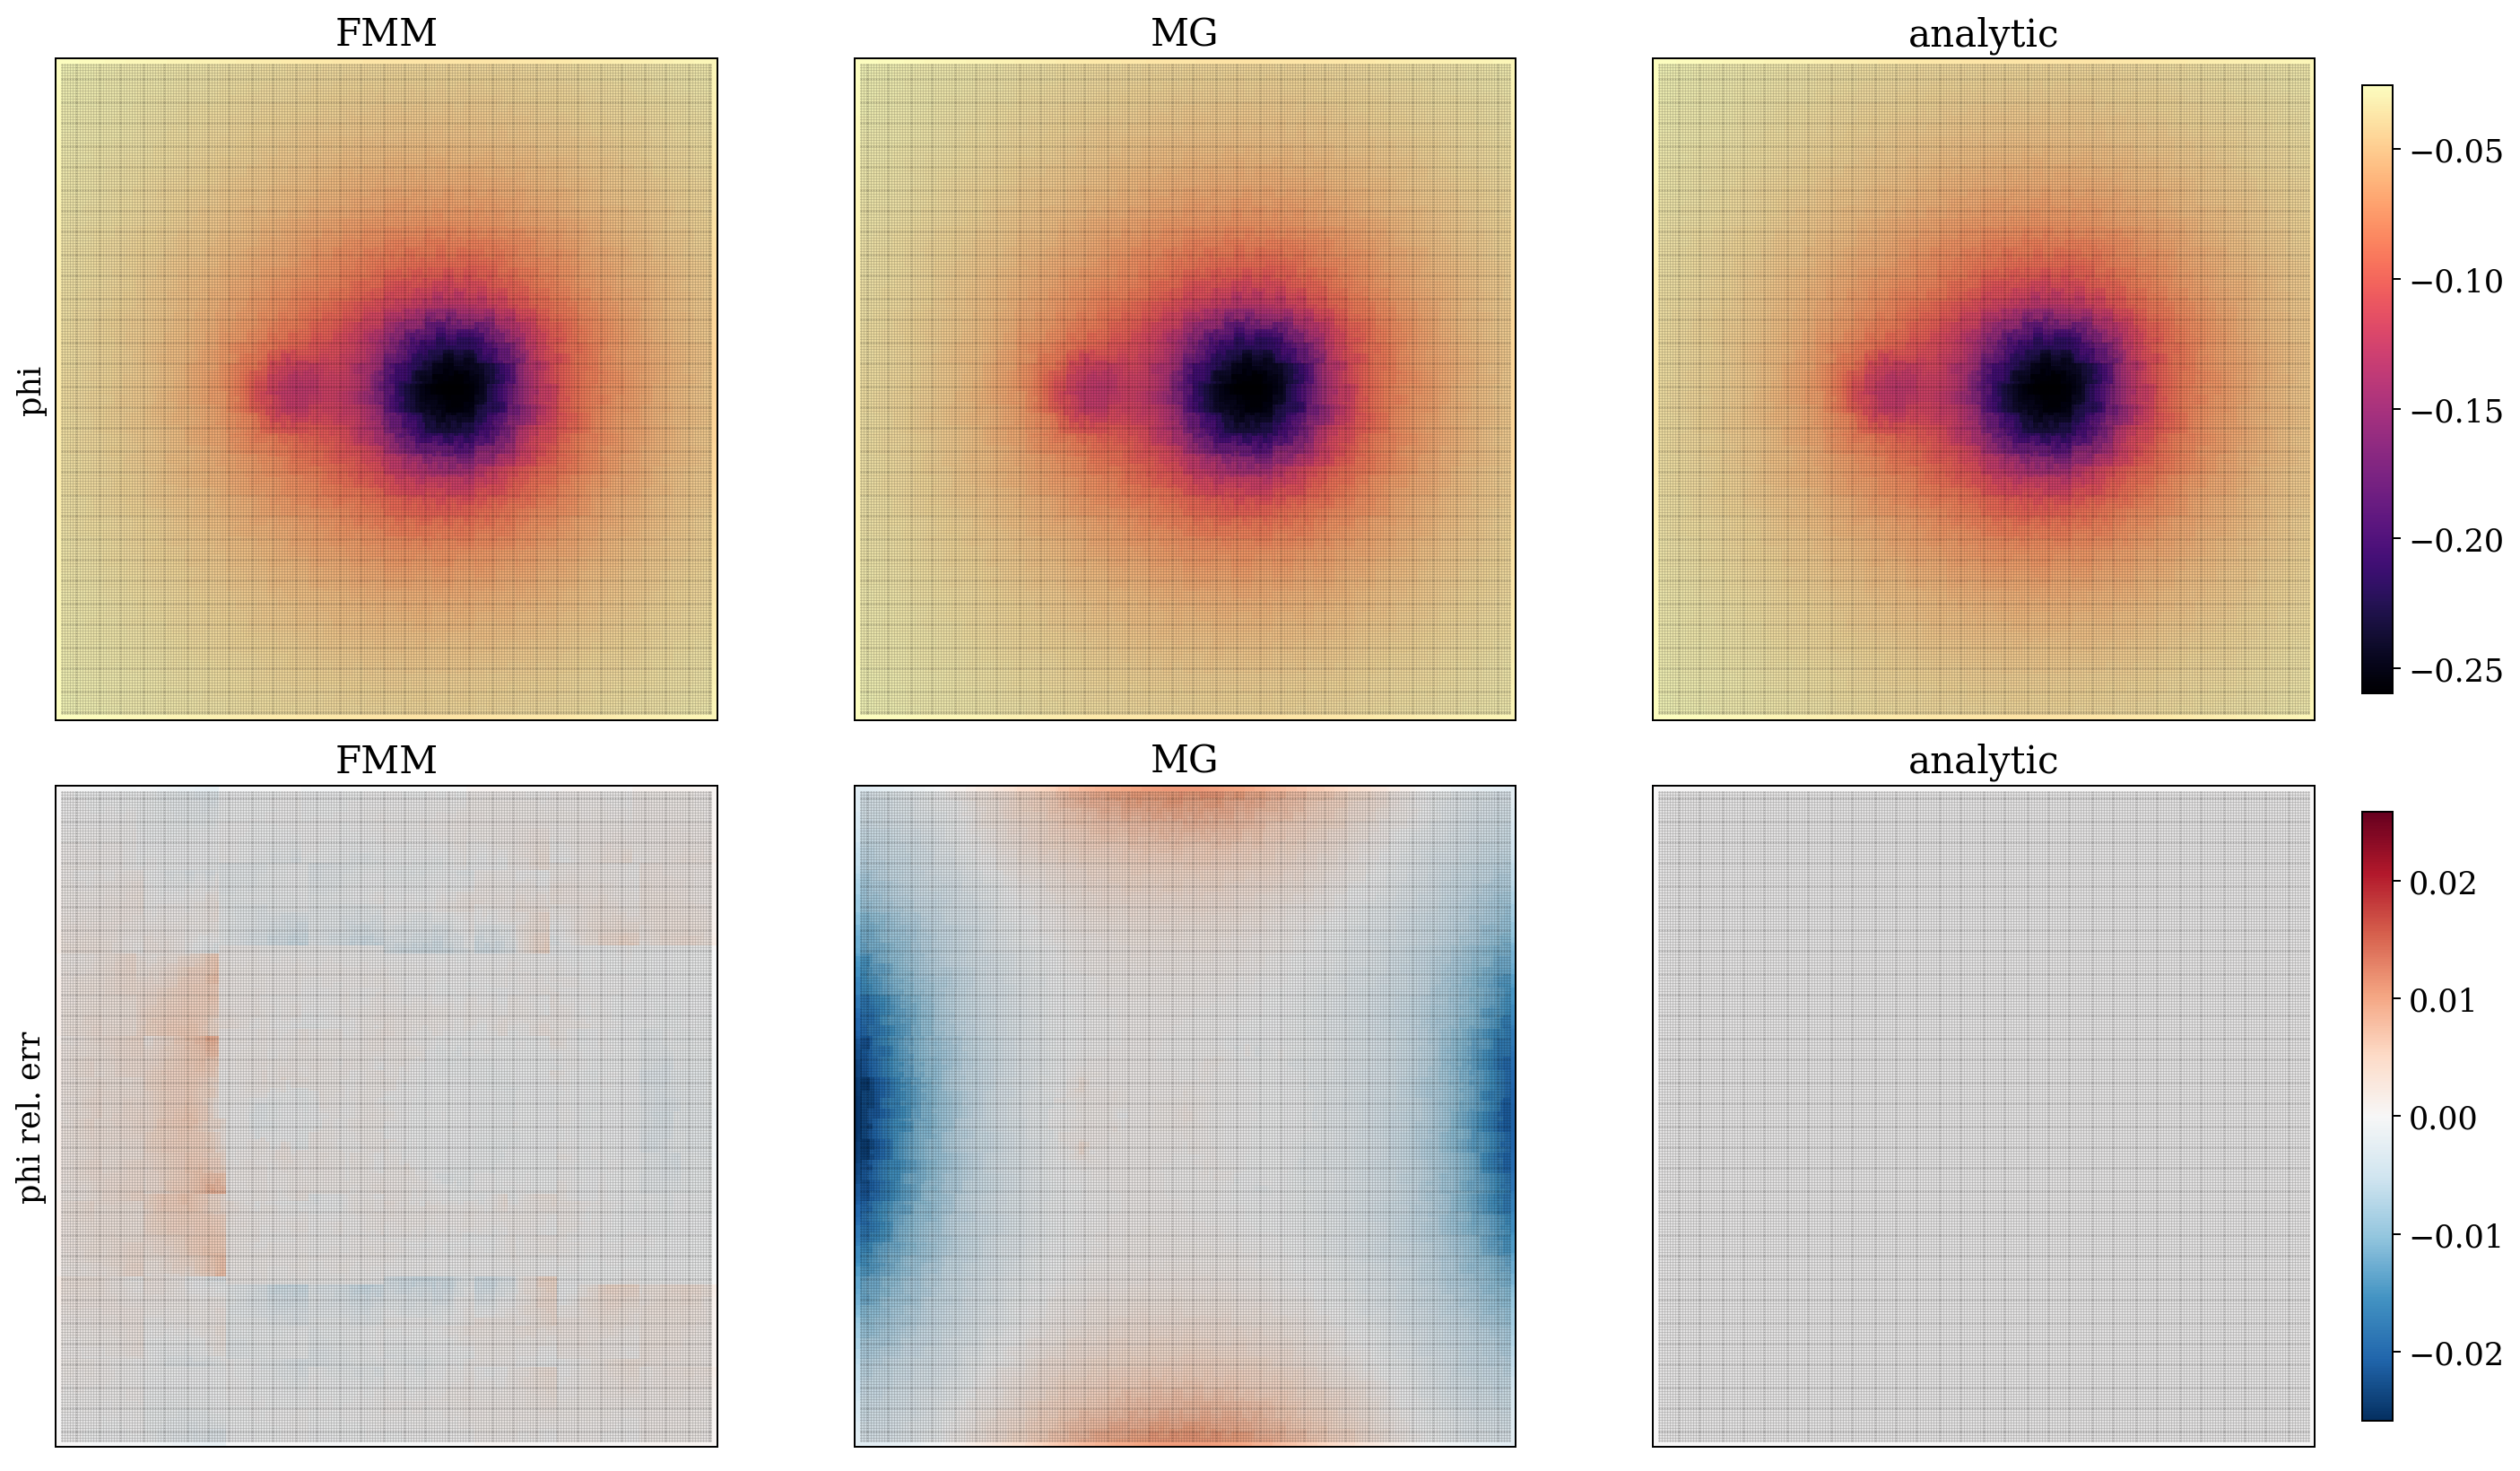

<Figure size 1080x720 with 0 Axes>

In [41]:
compare_two_solutions_with_analytic(
    s1,
    s2,
    quantity="phi",
    box=plot_box,
    npix=900,
    titles=("FMM", "MG", "analytic"),
    err_mode="signed",   # or "abs"
    grid=True,
    exclude_boundary=True
)

plt.savefig('phi.png')

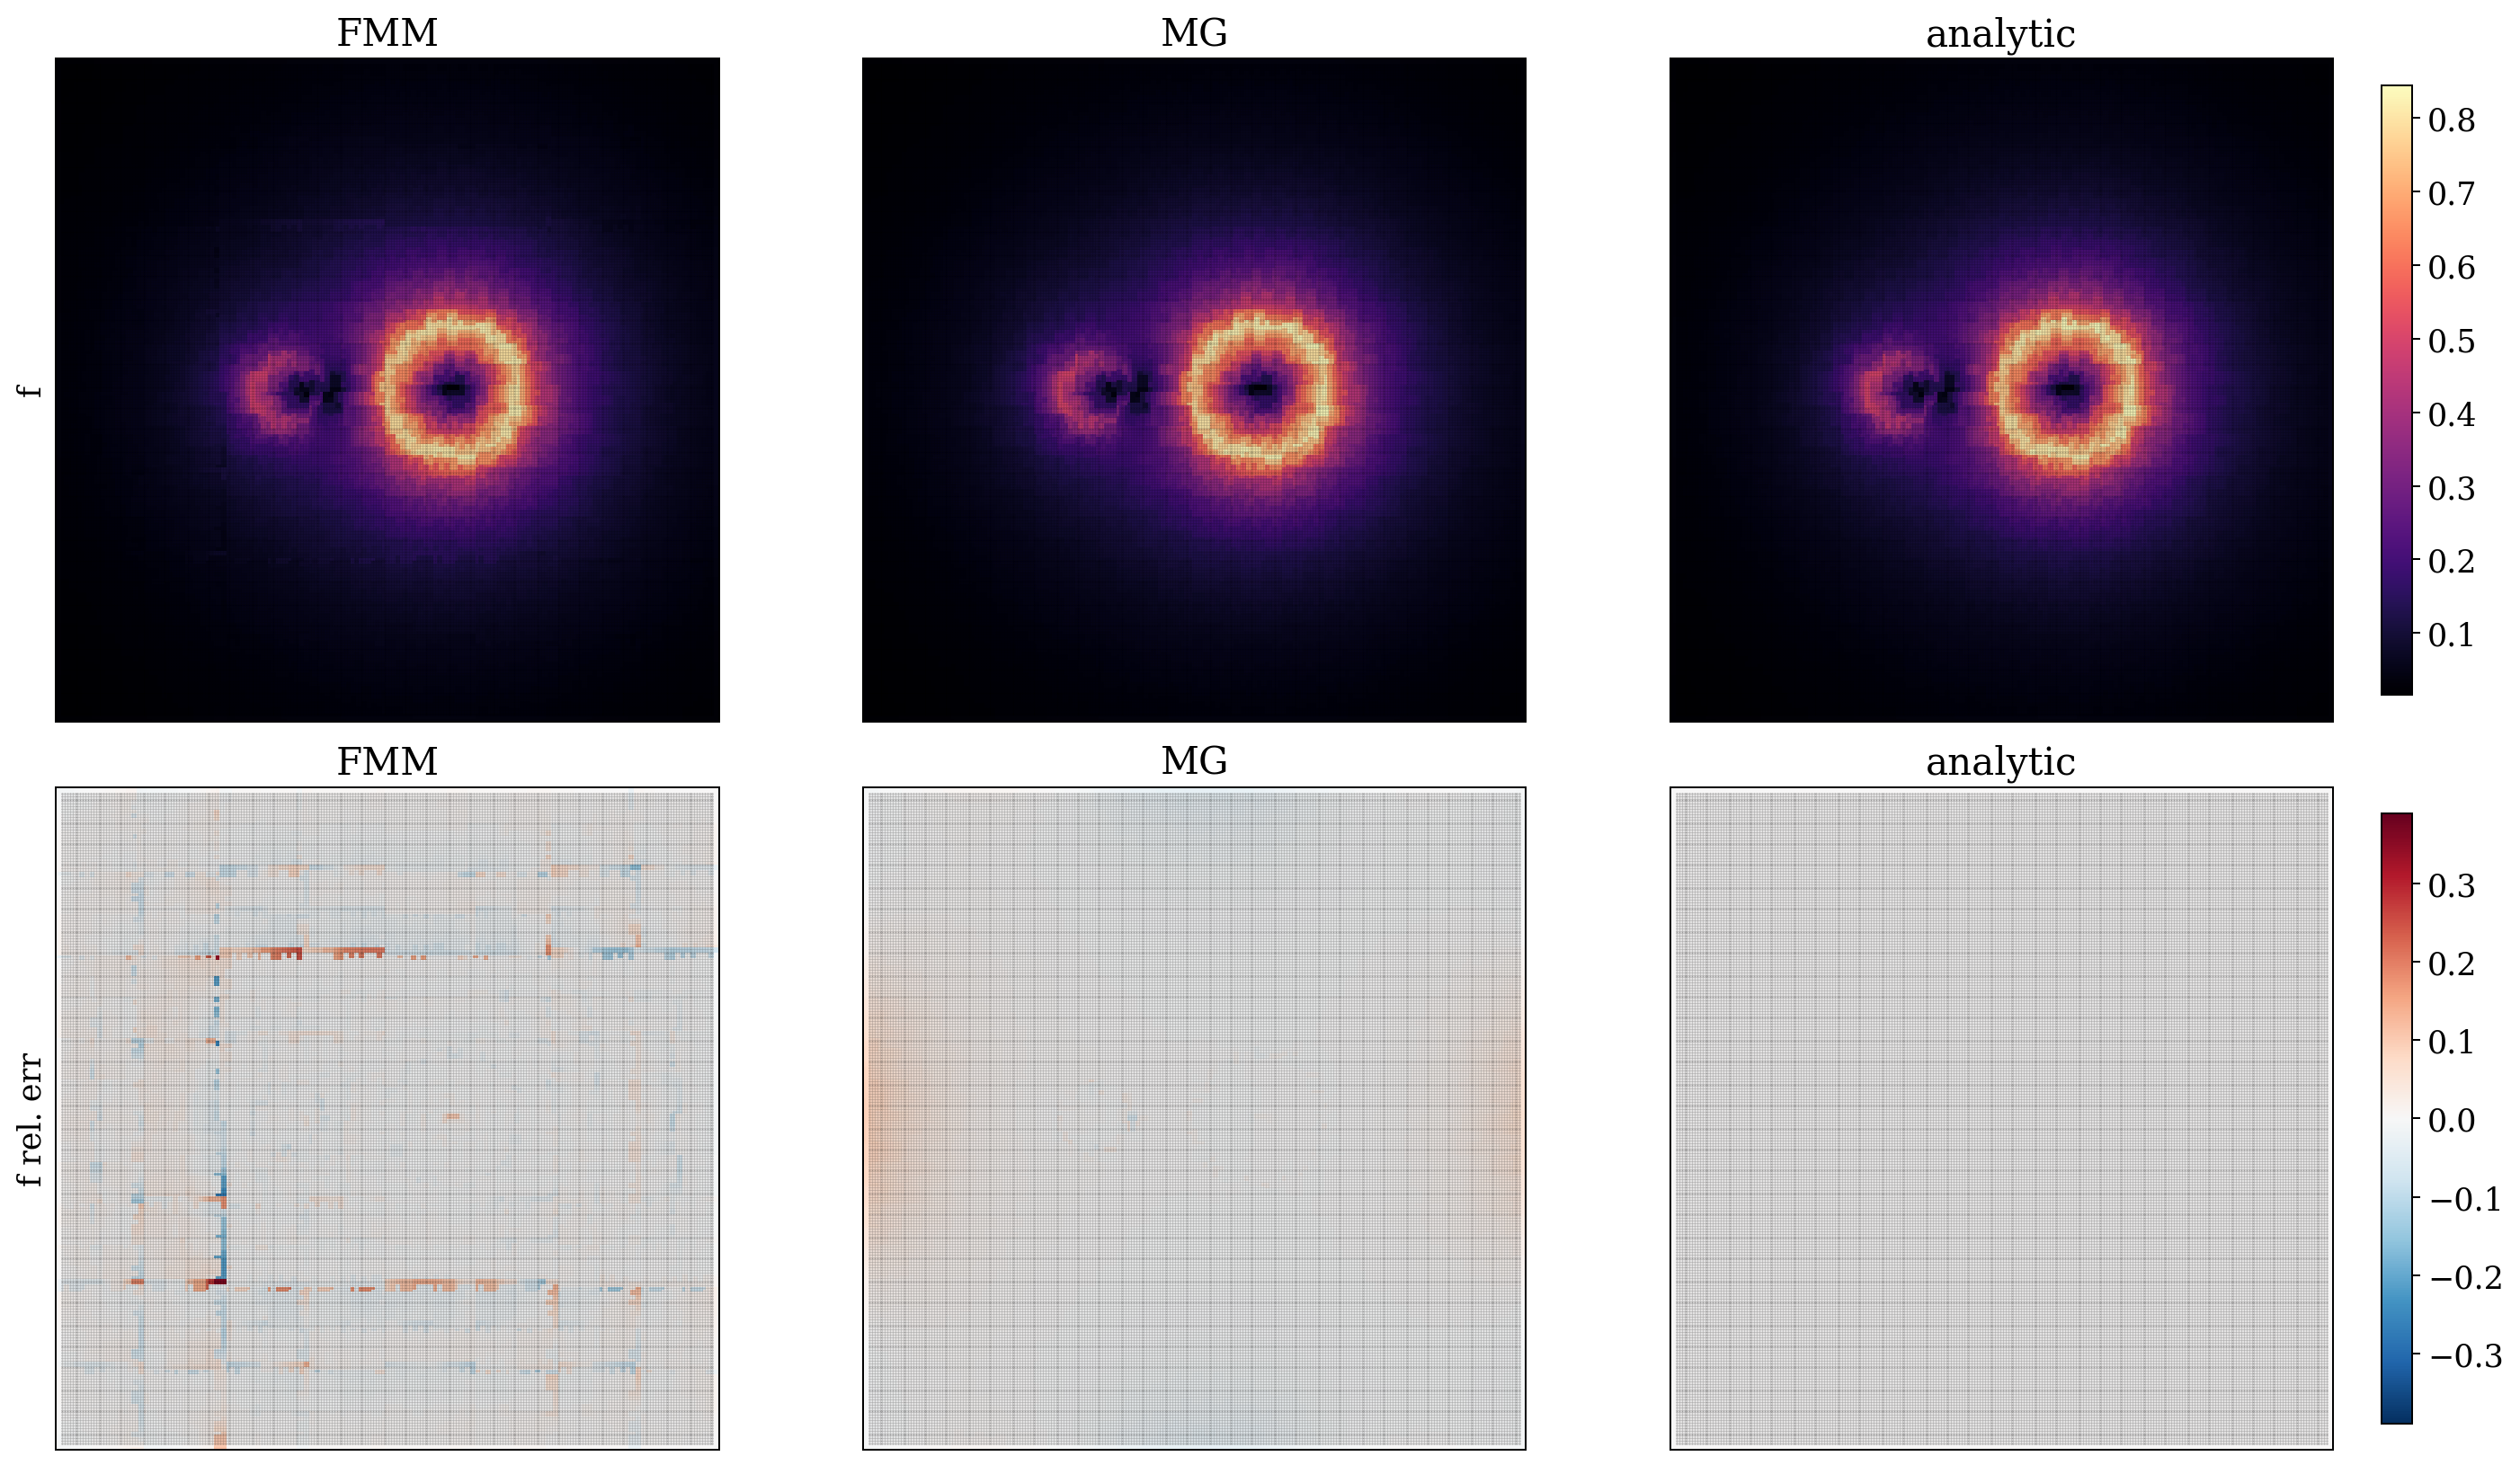

<Figure size 1080x720 with 0 Axes>

In [42]:
compare_two_solutions_with_analytic(
    s1,
    s2,
    quantity="f",
    box=plot_box,
    npix=900,
    titles=("FMM", "MG", "analytic"),
    err_mode="signed",   # or "abs"
    exclude_boundary=True, 
    grid = True
)
plt.savefig('f.png')

In [ ]:
# AMR refinement map for the slice.
# The color encodes the leaf-cell AMR level, so this shows the refinement regions directly.
c, s = ready(nout=2)
plot_refinement_map(s, box=plot_box, npix=900)

In [ ]:
compare_scalar_field(s1, quantity="phi", box=plot_box, npix=900, log=False, grid=True)

In [ ]:
compare_scalar_field(s, quantity="f", box=plot_box, npix=1200, log=True, grid=True)

In [ ]:
# Error statistics by AMR level.
plot_level_error_stats(s, quantity="phi")
plot_level_error_stats(s, quantity="f")


In [ ]:
# Midline profile across the slice.
# For the default z-slice this means a profile in x near the middle of y.
plot_midline_profile(s, quantity="phi", axis_in_plane="u")


## AMR Boundary Audit

These helpers separate `phi` errors into coarse-fine interface cells, domain-edge cells, interior cells, and sphere-surface-adjacent cells. They are useful for checking whether a small error tail is really caused by AMR boundary handling or by the analytic source geometry itself.


In [ ]:
from amr_phi_interface_audit import (
    audit_phi_amr_slice,
    plot_phi_amr_audit,
    plot_phi_amr_region_histogram,
    print_phi_amr_audit_summary,
)


In [ ]:
audit = audit_phi_amr_slice(
    s,
    box=plot_box,
    sphere_centers=(sphere1_center, sphere2_center),
    sphere_radii=(sphere1_radius, sphere2_radius),
    surface_factor=1.0,
)
print_phi_amr_audit_summary(audit, top_n=12)


In [ ]:
plot_phi_amr_audit(audit)
plot_phi_amr_region_histogram(audit)
plt.show()


## MG/FMM Phi Comparison

Compare raw `phi` values from the MG and FMM runs in `../tmp/mg_vs_fmm`.


In [ ]:
from pathlib import Path
from mg_fmm_phi_compare import (
    PLOT_BOX,
    SPHERE_CENTERS,
    SPHERE_RADII,
    align_slices,
    build_compare_slice,
    load_output,
    plot_compare_histogram,
    plot_compare_maps,
    print_summary,
    summarize_compare,
)


In [ ]:
mg_run = Path("../tmp/mg_vs_fmm/mg")
fmm_run = Path("../tmp/mg_vs_fmm/fmm")

mg_slice, info_mg = load_output(mg_run, 2)
fmm_slice, info_fmm = load_output(fmm_run, 2)
mg_slice, fmm_slice = align_slices(mg_slice, fmm_slice)
phi_compare = build_compare_slice(mg_slice, fmm_slice)
phi_compare_audit = audit_phi_amr_slice(
    phi_compare,
    box=PLOT_BOX,
    sphere_centers=SPHERE_CENTERS,
    sphere_radii=SPHERE_RADII,
    surface_factor=1.0,
)
phi_compare_summary = summarize_compare(info_mg, info_fmm, phi_compare)
print_summary(phi_compare_summary, phi_compare_audit)


In [ ]:
plot_compare_maps(phi_compare)
plot_compare_histogram(phi_compare, phi_compare_audit)
plt.show()
